<a href="https://colab.research.google.com/github/ZeckRyan/nlp-sentiment-analysis-zoo-park/blob/main/%5BP%5D_Sentiment_Analysis_Taman_Rimbo_Zoo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ecotourism Sentiment Analysis and Predictive Modeling: A Comparative Study of Machine Learning Algorithms

**Author:** Zakki Farian  
**Dataset:** Scraped Google Maps Reviews (Taman Rimbo Zoo)  

### 1. Objective
The primary objective of this project is to systematically classify public sentiment from unstructured textual data into discrete categories (Positive, Negative, Neutral). Furthermore, this study aims to evaluate and compare the efficacy of multiple machine learning algorithms—specifically linear models and ensemble methods—in handling high-dimensional, sparse, and imbalanced text data inherent in natural language processing (NLP) tasks.

### 2. Methodology and Approach
This project follows a rigorous, end-to-end Machine Learning pipeline architecture:

1. **Data Ingestion and Preprocessing:**
   Raw text data is subjected to noise reduction using Regular Expressions (Regex) to eliminate URLs, special characters, and numerical digits. Subsequently, morphological stemming and custom stopword elimination are applied utilizing the Sastrawi library to isolate core lexical features and reduce the dimensionality of the feature space.

2. **Feature Engineering (TF-IDF):**
   The preprocessed corpus is transformed into a sparse numerical matrix using Term Frequency-Inverse Document Frequency (TF-IDF). This statistical measure evaluates the relevance of a word to a document within the entire corpus.
   $$ \text{TF-IDF}(t, d, D) = \text{TF}(t, d) \times \left( \log \frac{N}{1 + \text{df}(t)} + 1 \right) $$
   *(Where $N$ is the total number of documents, and $\text{df}(t)$ is the document frequency of term $t$.)*

3. **Algorithmic Modeling:**
   To combat class imbalance, multiple classifiers are trained with balanced class weights. The selected algorithms include:
   * **Stochastic Gradient Descent (SGD) Classifier:** Optimizes the logistic loss function iteratively.
   * **Support Vector Machine (SVM):** Constructs an optimal hyperplane that maximizes the margin between classes. The optimization objective is defined as:
     $$ \min_{w, b} \frac{1}{2} ||w||^2 + C \sum_{i=1}^{n} \xi_i $$
   * **Random Forest:** An ensemble learning method utilizing multiple decision trees to reduce variance and prevent overfitting.

4. **Model Evaluation:**
   The models are evaluated on an isolated testing set. Performance is quantified using Accuracy, Precision, Recall, and the F1-Score, which provides the harmonic mean of precision and recall, making it highly robust for imbalanced datasets.
   $$ \text{F1-Score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}} $$

### Importing Libraries & Dependencies

In this initial phase, we import the foundational libraries required for our Natural Language Processing (NLP) pipeline.
* **Pandas & NumPy:** For high-performance data manipulation and linear algebra operations.
* **Scikit-Learn:** The core machine learning library. We utilize its `Pipeline` architecture to prevent data leakage, `TfidfVectorizer` for text vectorization, and `SGDClassifier` for optimization.
* **Sastrawi:** A specialized library for Indonesian morphology, crucial for accurate stemming and stopword removal.
* **Seaborn & Matplotlib:** For statistical data visualization, specifically to render the Confusion Matrix.
* **WordCloud:** For word visualization

In [18]:
pip install wordcloud sastrawi

In [19]:
import re
import string
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gdown
from wordcloud import WordCloud
from typing import Tuple, Dict

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Set visualization style
sns.set_theme(style="whitegrid")

## Advanced Pipeline Architecture (OOP)

We upgrade our `SentimentAnalysisPipeline` class to handle **Multi-Model Training** and **Text Visualization**.

### Mathematical Additions:
1. **Support Vector Machine (SVM):** Finds the optimal hyperplane that maximizes the margin between classes. Highly effective in high-dimensional TF-IDF spaces.
   $$ \min_{w, b} \frac{1}{2} ||w||^2 + C \sum_{i=1}^{n} \xi_i $$
2. **Random Forest:** An ensemble learning method that constructs a multitude of decision trees, reducing the variance (overfitting) often seen in highly imbalanced text data.

In [20]:
class SentimentAnalysisPipeline:
    """
    An advanced end-to-end Machine Learning pipeline handling multi-model
    training, evaluation, and styled text visualization.
    """
    def __init__(self, file_path: str, text_col: str = 'text', label_col: str = 'sentiment'):
        """
        Initializes the pipeline and pre-loads the Sastrawi NLP components.

        Methodological Enhancement:
        ---------------------------
        The default Sastrawi stopword list is extended with a custom array of
        colloquial Indonesian terms (slang) to ensure high-frequency, low-information
        words do not skew the TF-IDF matrix calculations.
        """
        self.file_path = file_path
        self.text_col = text_col
        self.label_col = label_col
        self.df = pd.DataFrame()
        self.trained_models: Dict[str, Pipeline] = {}

        print("Initializing NLP components (Sastrawi) with custom stopwords...")

        # 1. Retrieve the default Sastrawi stopwords
        factory = StopWordRemoverFactory()
        base_stopwords = factory.get_stop_words()

        # 2. Define custom colloquial stopwords observed in the EDA phase
        custom_stopwords =[
            'yg', 'nya', 'buat', 'aja', 'kalo', 'udah', 'deh', 'sih',
            'pas', 'bgt', 'banget', 'sama', 'ada', 'dari', 'ke', 'di',
            'ini', 'itu', 'dan', 'untuk', 'yang', 'juga', 'lagi'
        ]

        # 3. Merge and create a new StopWordRemover instance
        # We utilize ArrayDictionary to override the default factory settings
        from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemover, ArrayDictionary

        all_stopwords = base_stopwords + custom_stopwords
        dictionary = ArrayDictionary(all_stopwords)
        self.stopword_remover = StopWordRemover(dictionary)

        # 4. Initialize the Stemmer
        self.stemmer = StemmerFactory().create_stemmer()

    def load_data(self) -> None:
        print(f"Loading dataset from: {self.file_path}")
        self.df = pd.read_csv(self.file_path)
        self.df.dropna(subset=[self.text_col, self.label_col], inplace=True)
        print(f"Data loaded successfully. Total rows: {self.df.shape[0]}")

    def _clean_text(self, text: str) -> str:
        text = str(text).lower()
        text = re.sub(r'https?:\/\/\S+', '', text)
        text = ' '.join(re.sub("([@#][A-Za-z0-9]+)|(\w+:\/\/\S+)", " ", text).split())
        text = re.sub(r'(b\'{1,2})', "", text)
        text = re.sub('[^a-zA-Z]', ' ', text)
        text = re.sub(r'\d+', '', text)
        text = text.translate(str.maketrans("", "", string.punctuation))
        text = re.sub(r'\s+', ' ', text).strip()
        return text

    def _remove_stopwords_and_stem(self, text: str) -> str:
        text = self.stopword_remover.remove(text)
        text = self.stemmer.stem(text)
        return text

    def preprocess_data(self) -> None:
        print("Starting text preprocessing... (This might take a while)")
        start_time = time.time()

        self.df['clean_text'] = self.df[self.text_col].apply(self._clean_text)
        self.df['clean_text'] = self.df['clean_text'].apply(self._remove_stopwords_and_stem)
        self.df = self.df[self.df['clean_text'].str.strip() != '']

        elapsed_time = time.time() - start_time
        print(f"Preprocessing completed in {elapsed_time:.2f} seconds.")

    def visualize_wordclouds(self) -> None:
        """
        Generates and plots Word Clouds comparing raw text vs cleaned text.
        Includes a safety check to ensure preprocessing has been executed.
        """
        if 'clean_text' not in self.df.columns:
            print("'clean_text' column not found! Automatically running preprocess_data()...")
            self.preprocess_data()

        print("Generating Word Clouds...")
        raw_text_combined = ' '.join(self.df[self.text_col].astype(str))
        clean_text_combined = ' '.join(self.df['clean_text'].astype(str))

        wc_raw = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(raw_text_combined)
        wc_clean = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(clean_text_combined)

        fig, axes = plt.subplots(1, 2, figsize=(16, 8))

        axes[0].imshow(wc_raw, interpolation='bilinear')
        axes[0].set_title('Word Cloud: BEFORE Preprocessing (Raw)', fontsize=16, fontweight='bold')
        axes[0].axis('off')

        axes[1].imshow(wc_clean, interpolation='bilinear')
        axes[1].set_title('Word Cloud: AFTER Preprocessing (Cleaned)', fontsize=16, fontweight='bold')
        axes[1].axis('off')

        plt.tight_layout()
        plt.show()

    def split_data(self, test_size: float = 0.2, random_state: int = 42) -> Tuple:
        print("Splitting data into train and test sets...")
        X = self.df['clean_text']
        y = self.df[self.label_col]
        return train_test_split(X, y, test_size=test_size, random_state=random_state, stratify=y)

    def train_multiple_models(self, X_train: pd.Series, y_train: pd.Series) -> None:
        print("Building and training multiple Machine Learning Pipelines...")

        classifiers = {
            'SGD Classifier': SGDClassifier(loss='log_loss', penalty='l2', max_iter=1000, class_weight='balanced', random_state=42),
            'Support Vector Machine': SVC(kernel='linear', class_weight='balanced', random_state=42),
            'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
        }

        for model_name, classifier in classifiers.items():
            print(f"Training {model_name}...")
            pipeline = Pipeline([
                ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
                ('clf', classifier)
            ])
            pipeline.fit(X_train, y_train)
            self.trained_models[model_name] = pipeline

        print("All models trained successfully.")

    def evaluate_and_compare_models(self, X_test: pd.Series, y_test: pd.Series) -> None:
        print("Evaluating models on the test set...\n")
        model_accuracies = {}

        for model_name, pipeline in self.trained_models.items():
            y_pred = pipeline.predict(X_test)
            acc = accuracy_score(y_test, y_pred)
            model_accuracies[model_name] = acc

            report_dict = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
            report_df = pd.DataFrame(report_dict).T

            styled_df = report_df.style.background_gradient(
                cmap='coolwarm',
                subset=['precision', 'recall', 'f1-score']
            ).format("{:.3f}")

            print(f"\nClassification Report for {model_name}:")
            display(styled_df)

        plt.figure(figsize=(10, 6))
        sns.barplot(x=list(model_accuracies.keys()), y=list(model_accuracies.values()), palette='viridis')

        plt.title('Model Accuracy Comparison', fontsize=16, fontweight='bold')
        plt.ylabel('Accuracy Score', fontsize=12)
        plt.ylim(0, 1.1)

        for index, value in enumerate(model_accuracies.values()):
            plt.text(index, value + 0.02, f"{value * 100:.2f}%", ha='center', fontweight='bold', fontsize=12)

        plt.tight_layout()
        plt.show()

<>:55: SyntaxWarning: invalid escape sequence '\w'
<>:55: SyntaxWarning: invalid escape sequence '\w'
/tmp/ipykernel_3059/3100553545.py:55: SyntaxWarning: invalid escape sequence '\w'
  text = ' '.join(re.sub("([@#][A-Za-z0-9]+)|(\w+:\/\/\S+)", " ", text).split())


### Data Acquisition

To ensure strict **reproducibility** of this notebook, we automate the data ingestion process. The dataset is hosted securely on Google Drive, and we programmatically fetch it using the `gdown` library.

By defining the output filename explicitly, we prevent any `FileNotFoundError` in the subsequent pipeline initialization steps.

In [21]:
# Define the Google Drive file ID
files =[
    '1OtvvnBfwGpY_4qRInjS2CjiNfq-g11-8'
    ]

# Define the explicit output name for the downloaded file
DOWNLOADED_FILENAME = 'dataset_reviews.csv'

print("Starting data acquisition from Google Drive...")

for file in files:
    url = f'https://drive.google.com/uc?id={file}'
    # Download and save it with a specific name
    gdown.download(url, DOWNLOADED_FILENAME, quiet=False)

print(f"Data successfully downloaded and saved as: {DOWNLOADED_FILENAME}")

Starting data acquisition from Google Drive...


Downloading...
From: https://drive.google.com/uc?id=1OtvvnBfwGpY_4qRInjS2CjiNfq-g11-8
To: /content/dataset_reviews.csv
100%|██████████| 85.9k/85.9k [00:00<00:00, 31.7MB/s]

Data successfully downloaded and saved as: dataset_reviews.csv


### Initialization & Data Loading

We instantiate our `SentimentAnalysisPipeline` class. We pass the `DOWNLOADED_FILENAME` we just acquired from Google Drive. The `load_data()` method ensures that any corrupted rows (NaNs) are dropped to maintain mathematical integrity before vectorization.

In [22]:
# Define configurations
FILE_PATH = '/content/dataset_reviews.csv'
TEXT_COLUMN = 'text'
LABEL_COLUMN = 'sentiment'

# Instantiate the pipeline class
nlp_pipeline = SentimentAnalysisPipeline(
    file_path=FILE_PATH,
    text_col=TEXT_COLUMN,
    label_col=LABEL_COLUMN
)

# Load the dataset
nlp_pipeline.load_data()

# Display the first 3 rows to verify
nlp_pipeline.df.head(3)

Initializing NLP components (Sastrawi) with custom stopwords...
Loading dataset from: /content/dataset_reviews.csv
Data loaded successfully. Total rows: 264


,Unnamed: 0,reviewer_name,reviewer_profile_url,reviewer_profile_pic,stars,text,date,photos,sentiment
0,0,Hastea,https://www.google.com/maps/contrib/1182737274...,https://lh3.googleusercontent.com/a-/ALV-UjUr7...,[1],Udah jauh² ke sini ada tulisan tutup karena ka...,"1,74E+15",NaN,NEGATIF
1,1,Ira Zahirah Nurwannisa,https://www.google.com/maps/contrib/1076155476...,https://lh3.googleusercontent.com/a-/ALV-UjUxd...,[1],tai bgt di maps tutup jam 4 sampe tmpt tulisan...,"1,74E+15",NaN,NEGATIF
2,2,Wahyu Setiawan,https://www.google.com/maps/contrib/1079658459...,https://lh3.googleusercontent.com/a-/ALV-UjUMY...,[1],"Niatnya mau healing tapi bapaknya galak, n jal...","1,73E+15",NaN,NEGATIF


## Text Visualization: Word Cloud Analysis

Before training the model, it is crucial to visually inspect the impact of our preprocessing steps.
* The **Raw Word Cloud** typically contains noisy words, conjunctions, and uninformative terms.
* The **Cleaned Word Cloud** should highlight the core morphological roots (stems) that carry the actual sentiment weight.

'clean_text' column not found! Automatically running preprocess_data()...
Starting text preprocessing... (This might take a while)
Preprocessing completed in 61.83 seconds.
Generating Word Clouds...


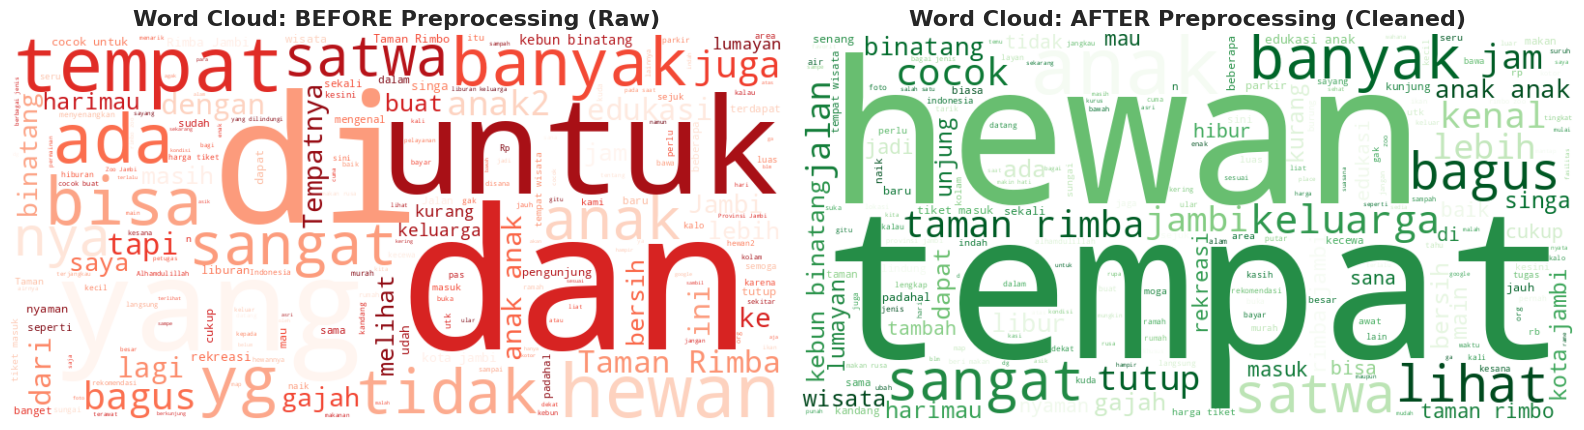

In [23]:
# Generate Word Clouds
nlp_pipeline.visualize_wordclouds()

## Multi-Model Training & Evaluation

To combat the **Class Imbalance** issue (specifically the lack of 'NETRAL' reviews), we train three distinct algorithms:
1. **SGD Classifier**
2. **Support Vector Machine (SVM)**
3. **Random Forest**

All models are configured with `class_weight='balanced'` to heavily penalize misclassifications of the minority class.

Splitting data into train and test sets...
Building and training multiple Machine Learning Pipelines...
Training SGD Classifier...
Training Support Vector Machine...
Training Random Forest...
All models trained successfully.
Evaluating models on the test set...


Classification Report for SGD Classifier:


,precision,recall,f1-score,support
NEGATIF,0.875,0.538,0.667,13.000
NETRAL,0.000,0.000,0.000,5.000
POSITIF,0.756,0.971,0.850,35.000
accuracy,0.774,0.774,0.774,0.774
macro avg,0.544,0.503,0.506,53.000
weighted avg,0.714,0.774,0.725,53.000



Classification Report for Support Vector Machine:


,precision,recall,f1-score,support
NEGATIF,0.889,0.615,0.727,13.000
NETRAL,0.000,0.000,0.000,5.000
POSITIF,0.773,0.971,0.861,35.000
accuracy,0.792,0.792,0.792,0.792
macro avg,0.554,0.529,0.529,53.000
weighted avg,0.728,0.792,0.747,53.000



Classification Report for Random Forest:


,precision,recall,f1-score,support
NEGATIF,1.000,0.231,0.375,13.000
NETRAL,0.000,0.000,0.000,5.000
POSITIF,0.700,1.000,0.824,35.000
accuracy,0.717,0.717,0.717,0.717
macro avg,0.567,0.410,0.400,53.000
weighted avg,0.708,0.717,0.636,53.000


/tmp/ipykernel_3059/3100553545.py:155: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(model_accuracies.keys()), y=list(model_accuracies.values()), palette='viridis')


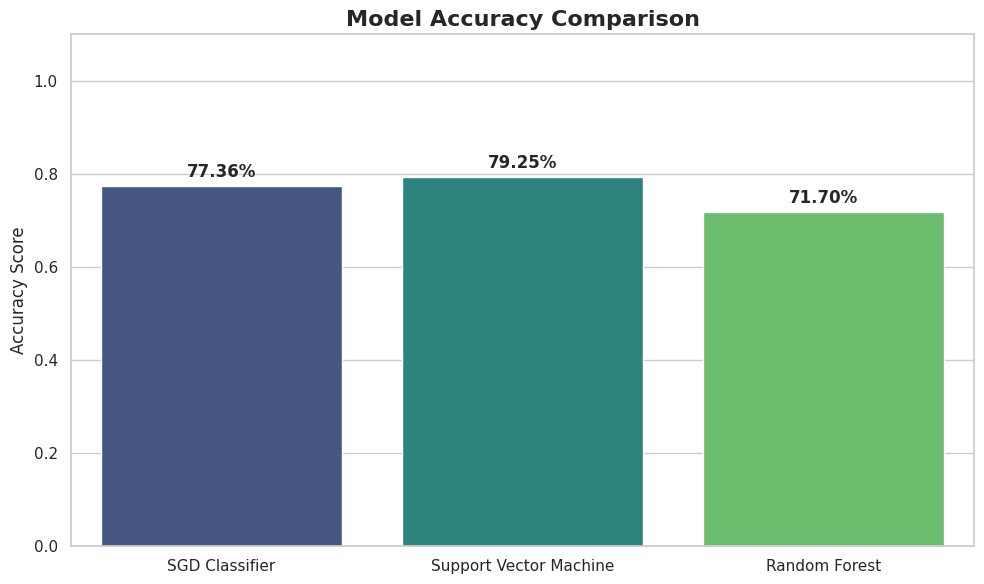

In [27]:
# Split the data
X_train, X_test, y_train, y_test = nlp_pipeline.split_data(test_size=0.2, random_state=42)

# Train all models
nlp_pipeline.train_multiple_models(X_train, y_train)

# Evaluate and compare all models
nlp_pipeline.evaluate_and_compare_models(X_test, y_test)